# 01 — Preprocessing, Image Index & ACS_WSI Dataset

1. Build dome mask and visualise exclusion region
2. Three representative images: original → masked → reprojected
3. Brightness distribution to validate the daytime threshold
4. Full image index with monthly/diurnal counts
5. ACS_WSI dataset loader — sample pairs across CF levels
6. CF distribution across all 77 ACS_WSI pairs

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from skycamera.config import CX, CY, R, OUT_H, OUT_W, BRIGHTNESS_THRESHOLD, FULL_RAW_DIR, CF_MAX_ZENITH_DEG, DAYTIME_MIN_ELEVATION_DEG
from skycamera.io import (
    load_image, is_daytime, is_daytime_brightness, sun_elevation,
    build_image_index, load_acs_wsi_dataset, load_acs_wsi_pair,
)
from skycamera.preprocessing import (
    build_circular_mask, apply_mask, fisheye_to_equirectangular,
    build_zenith_weight_map, weighted_cf,
)

RAW_ROOT = FULL_RAW_DIR   # data/full_raw/ — full year, thinned to 30-min intervals
ACS_ROOT = Path('D:/MOJE/DATA_SCIENCE/SKYCAMERA/ACS_WSI-v1.0.0')

print(f'Camera: CX={CX}  CY={CY}  R={R}')
print(f'Output size: {OUT_H}x{OUT_W}  |  Brightness threshold: {BRIGHTNESS_THRESHOLD}')
print(f'CF max zenith: {CF_MAX_ZENITH_DEG}°')
print(f'Daytime threshold: solar elevation ≥ {DAYTIME_MIN_ELEVATION_DEG}° (civil twilight)')
print(f'Image root: {RAW_ROOT}')

Camera: CX=1438  CY=928  R=938
Output size: 512x512  |  Brightness threshold: 20.0
CF max zenith: 70.0°
Daytime threshold: solar elevation ≥ -6.0° (civil twilight)
Image root: D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\full_raw


## 1. Dome mask

Native resolution : 3096 x 2080 px
Dome pixels       : 2,762,359  (42.9% of frame)


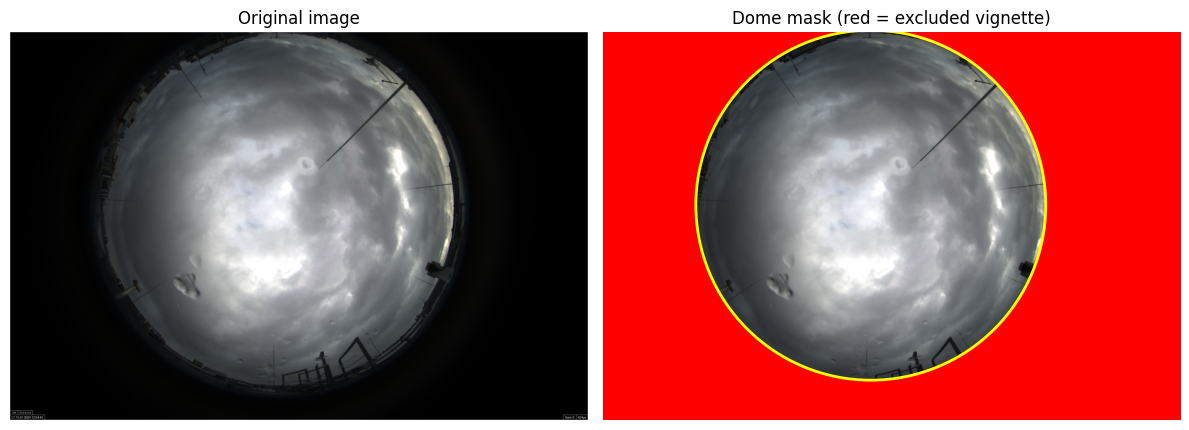

In [2]:
_sample = load_image(RAW_ROOT / '2024-01-15' / '2024_01_15__12_04_51.jpg')
IMG_H, IMG_W = _sample.shape[:2]
dome_mask = build_circular_mask(IMG_H, IMG_W, CX, CY, R)

print(f'Native resolution : {IMG_W} x {IMG_H} px')
print(f'Dome pixels       : {dome_mask.sum():,}  ({dome_mask.sum() / (IMG_H * IMG_W) * 100:.1f}% of frame)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(_sample)
axes[0].set_title('Original image')
axes[0].axis('off')

overlay = _sample.copy()
overlay[~dome_mask] = [255, 0, 0]
axes[1].imshow(overlay)
axes[1].set_title('Dome mask (red = excluded vignette)')
axes[1].axis('off')
circle = mpatches.Circle((CX, CY), R, fill=False, edgecolor='yellow', linewidth=2)
axes[1].add_patch(circle)

fig.tight_layout()
plt.show()

## 2. Three representative images: original | masked | reprojected

January (overcast?): brightness=124.6
June (clear/cumulus?): brightness=77.5
November (overcast?): brightness=116.4


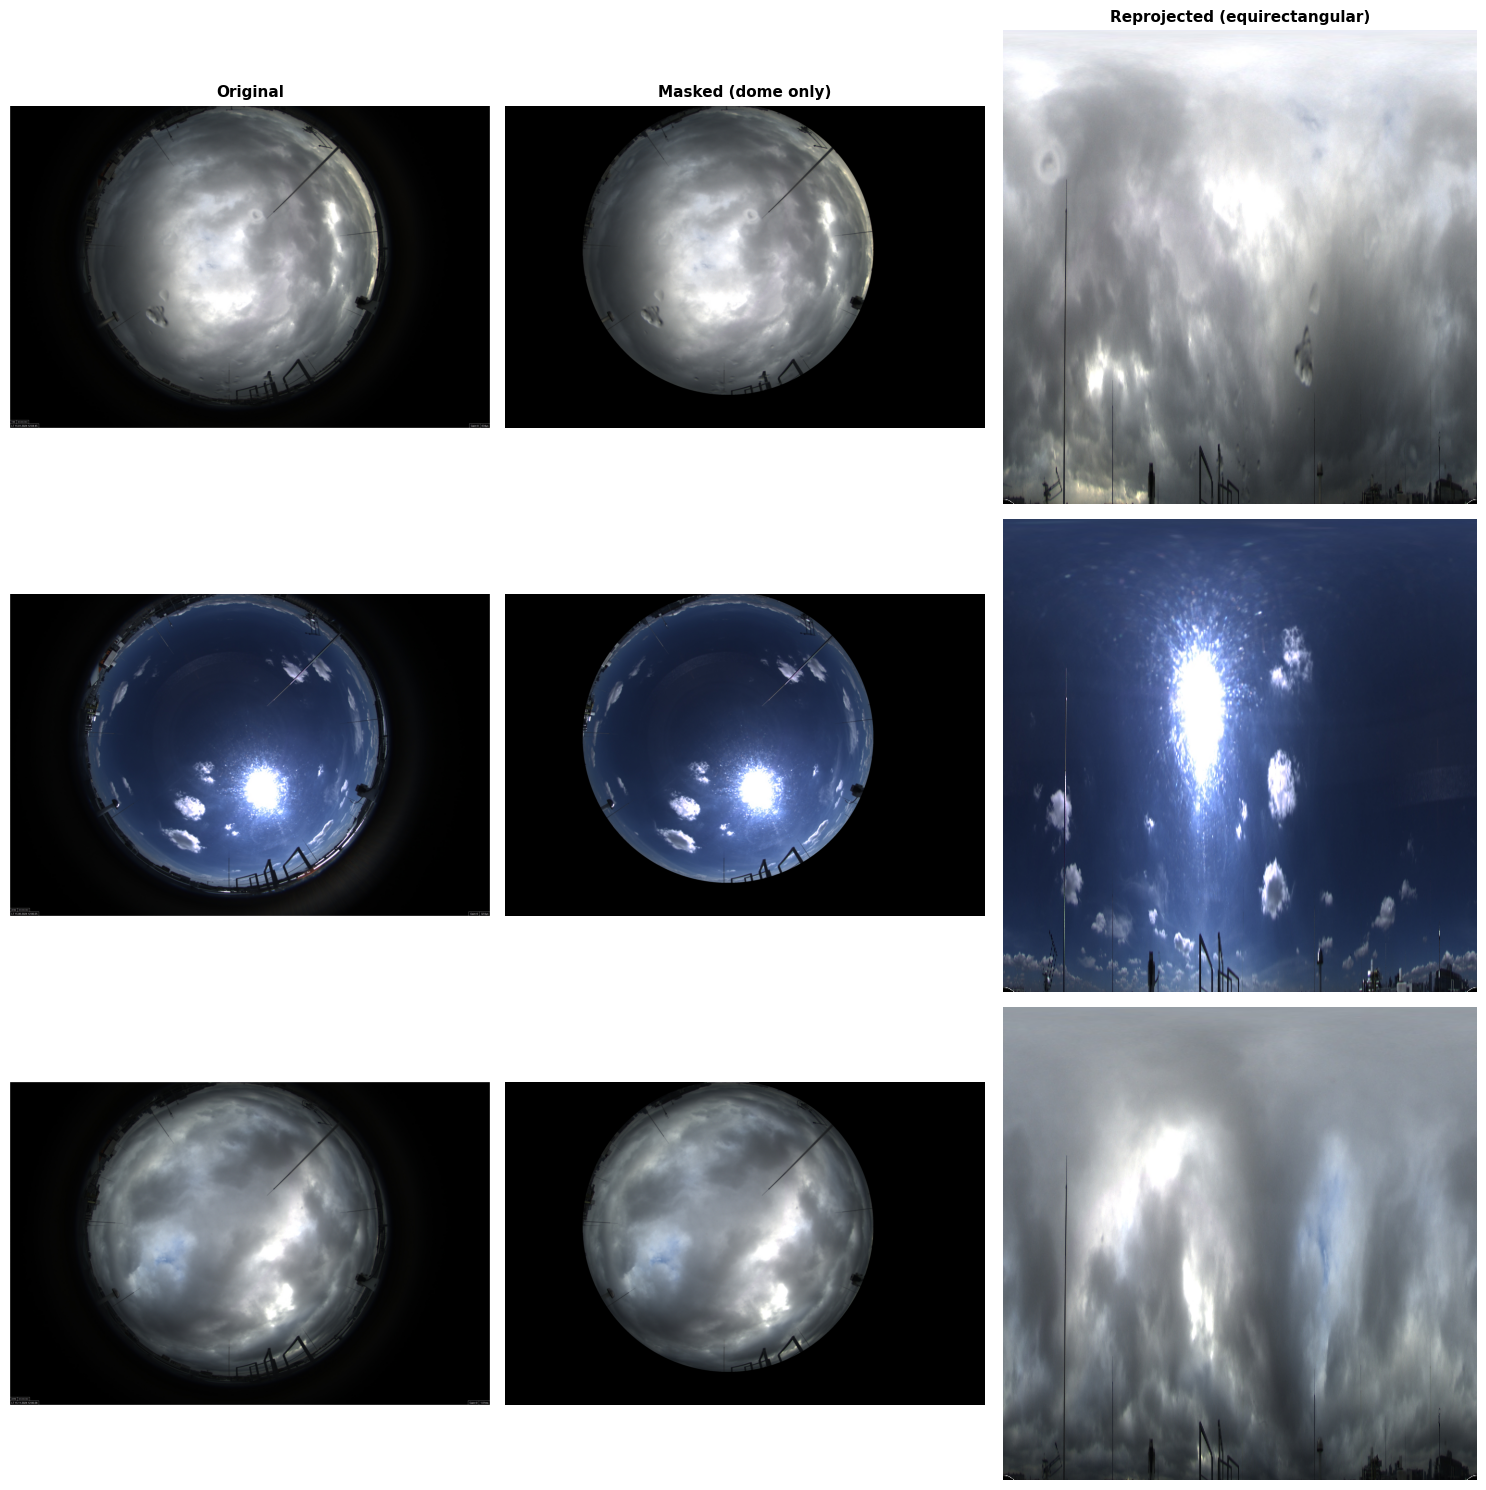

In [3]:
SAMPLES = {
    'January (overcast?)':   RAW_ROOT / '2024-01-15' / '2024_01_15__12_04_51.jpg',
    'June (clear/cumulus?)': RAW_ROOT / '2024-06-15' / '2024_06_15__12_00_31.jpg',
    'November (overcast?)':  RAW_ROOT / '2024-11-15' / '2024_11_15__12_00_34.jpg',
}

fig, axes = plt.subplots(len(SAMPLES), 3, figsize=(15, 5 * len(SAMPLES)))
for ax, title in zip(axes[0], ['Original', 'Masked (dome only)', 'Reprojected (equirectangular)']):
    ax.set_title(title, fontsize=11, fontweight='bold')

for row_idx, (label, fpath) in enumerate(SAMPLES.items()):
    img    = load_image(fpath)
    masked = apply_mask(img, dome_mask)
    reproj = fisheye_to_equirectangular(img, CX, CY, R, OUT_H, OUT_W)
    axes[row_idx][0].imshow(img);     axes[row_idx][0].set_ylabel(label, fontsize=10)
    axes[row_idx][1].imshow(masked)
    axes[row_idx][2].imshow(reproj)
    for ax in axes[row_idx]: ax.axis('off')
    print(f'{label}: brightness={img.mean(axis=2)[dome_mask].mean():.1f}')

fig.tight_layout()
plt.savefig('../outputs/plots/preprocessing_samples.png', bbox_inches='tight', dpi=100)
plt.show()

## 3. Brightness distribution — daytime threshold validation

Sampled 1670 images
Brightness-based daytime: 1670
Astronomical daytime    : 1663
Disagreements           : 7 (0.4%)


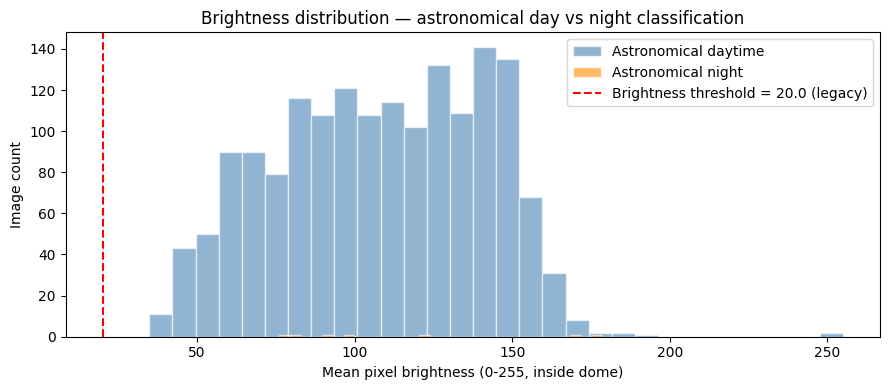

In [4]:
# Sample images to compare brightness threshold vs astronomical daytime classification
brightness_values = []
astro_daytime     = []
for month_dir in sorted(RAW_ROOT.glob('2024-*')):
    for fpath in sorted(month_dir.glob('*.jpg'))[:5]:
        try:
            img = load_image(fpath)
            brightness_values.append(float(img.mean(axis=2)[dome_mask].mean()))
            from skycamera.io import parse_timestamp
            ts = parse_timestamp(fpath)
            astro_daytime.append(is_daytime(ts) if ts else False)
        except Exception:
            pass

brightness_arr = np.array(brightness_values)
astro_arr      = np.array(astro_daytime)
print(f'Sampled {len(brightness_arr)} images')
print(f'Brightness-based daytime: {(brightness_arr >= BRIGHTNESS_THRESHOLD).sum()}')
print(f'Astronomical daytime    : {astro_arr.sum()}')
disagree = (brightness_arr >= BRIGHTNESS_THRESHOLD) != astro_arr
print(f'Disagreements           : {disagree.sum()} ({disagree.mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(brightness_arr[astro_arr],  bins=30, color='steelblue',  alpha=0.6,
        edgecolor='white', label='Astronomical daytime')
ax.hist(brightness_arr[~astro_arr], bins=30, color='darkorange', alpha=0.6,
        edgecolor='white', label='Astronomical night')
ax.axvline(BRIGHTNESS_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Brightness threshold = {BRIGHTNESS_THRESHOLD} (legacy)')
ax.set_xlabel('Mean pixel brightness (0-255, inside dome)')
ax.set_ylabel('Image count')
ax.set_title('Brightness distribution — astronomical day vs night classification')
ax.legend()
fig.tight_layout()
plt.savefig('../outputs/plots/brightness_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

## 4. Full image index with monthly and diurnal counts

`build_image_index` loads every image to compute brightness — cached to CSV after first run.

In [5]:
INDEX_CSV = Path('../outputs/csv/image_index.csv')

if INDEX_CSV.exists():
    print('Loading cached index...')
    df_index = pd.read_csv(INDEX_CSV, parse_dates=['timestamp'])
    df_index['path'] = df_index['path'].apply(Path)
else:
    print('Building index (fast — astronomical daytime filter, no image loading)...')
    df_index = build_image_index(RAW_ROOT, apply_daytime_filter=True)
    INDEX_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_index.to_csv(INDEX_CSV, index=False)
    print(f'Saved -> {INDEX_CSV}')

print(f'Total images      : {len(df_index):,}')
print(f'Daytime (elev≥{DAYTIME_MIN_ELEVATION_DEG}°): {df_index["is_daytime"].sum():,}')
print(f'Night             : {(~df_index["is_daytime"]).sum():,}  (flagged is_daytime=False — still in index)')
if 'sun_elevation_deg' in df_index.columns:
    print(f'Sun elevation: min={df_index["sun_elevation_deg"].min():.1f}°  '
          f'max={df_index["sun_elevation_deg"].max():.1f}°  '
          f'mean(daytime)={df_index.loc[df_index["is_daytime"],"sun_elevation_deg"].mean():.1f}°')
df_index.head()

Building index (fast — astronomical daytime filter, no image loading)...
Saved -> ..\outputs\csv\image_index.csv
Total images      : 17,145
Daytime (elev≥-6.0°): 9,637
Night             : 7,508  (flagged is_daytime=False — still in index)
Sun elevation: min=-61.2°  max=61.2°  mean(daytime)=21.7°


,path,timestamp,month,hour,sun_elevation_deg,is_daytime
0,D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\...,2024-01-01 12:00:41,1,12,12.73,True
1,D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\...,2024-01-01 12:31:23,1,12,10.93,True
2,D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\...,2024-01-01 13:02:05,1,13,8.63,True
3,D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\...,2024-01-01 13:27:40,1,13,6.38,True
4,D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\...,2024-01-01 13:58:20,1,13,3.36,True


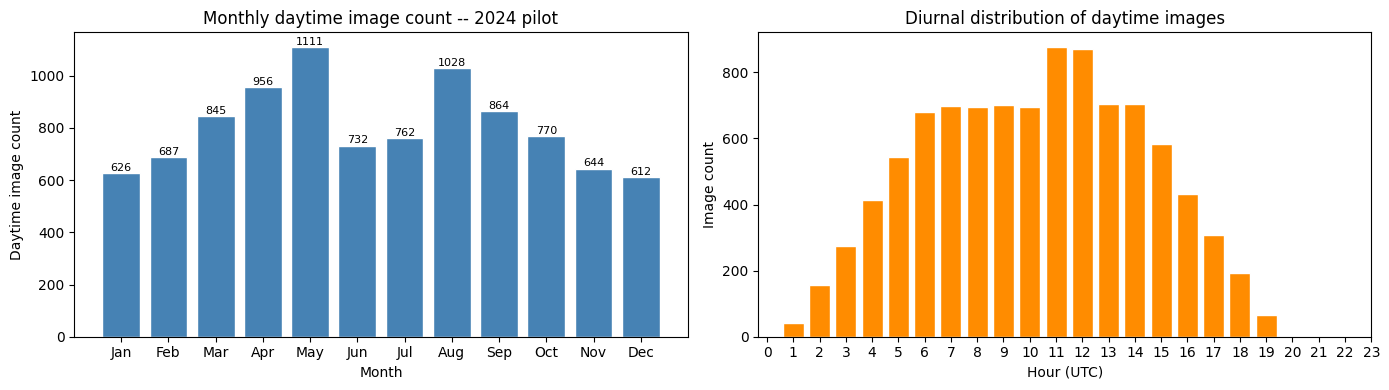

In [6]:
day_df = df_index[df_index['is_daytime']]
monthly = day_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Daytime image count')
axes[0].set_title('Monthly daytime image count -- 2024 pilot')
for bar, val in zip(bars, monthly.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(val), ha='center', va='bottom', fontsize=8)

hourly = day_df.groupby('hour').size()
axes[1].bar(hourly.index, hourly.values, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Image count')
axes[1].set_title('Diurnal distribution of daytime images')
axes[1].set_xticks(range(0, 24))

fig.tight_layout()
plt.savefig('../outputs/plots/image_index_counts.png', bbox_inches='tight', dpi=100)
plt.show()

## 5. ACS_WSI Dataset — sample pairs across CF levels

### GT mask encoding (verified by pixel inspection)

The GT masks use **colour coding**, not binary black/white as originally assumed:

| Colour | RGB (approx.) | Class |
|--------|---------------|-------|
| Black  | [0, 0, 0]     | Outside dome / no-data |
| Blue   | [0, 0, 87]    | Sky (clear) |
| Violet | [30, 30, 190] | Cloud |

JPEG compression blurs transitions between these pure colours.
Binarisation threshold: **red channel > 15 → cloud**, else sky (when not outside dome).

In [7]:
df_acs = load_acs_wsi_dataset(ACS_ROOT)
print(f'ACS_WSI dataset: {len(df_acs)} image/mask pairs')
print(f'CF levels: {sorted(df_acs["cf_level"].unique())}')
df_acs.head()

ACS_WSI dataset: 77 image/mask pairs
CF levels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,image_path,mask_path,cf_level,cf_approx
0,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,0,0.0
1,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,0,0.0
2,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,0,0.0
3,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,0,0.0
4,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,D:\MOJE\DATA_SCIENCE\SKYCAMERA\ACS_WSI-v1.0.0\...,0,0.0


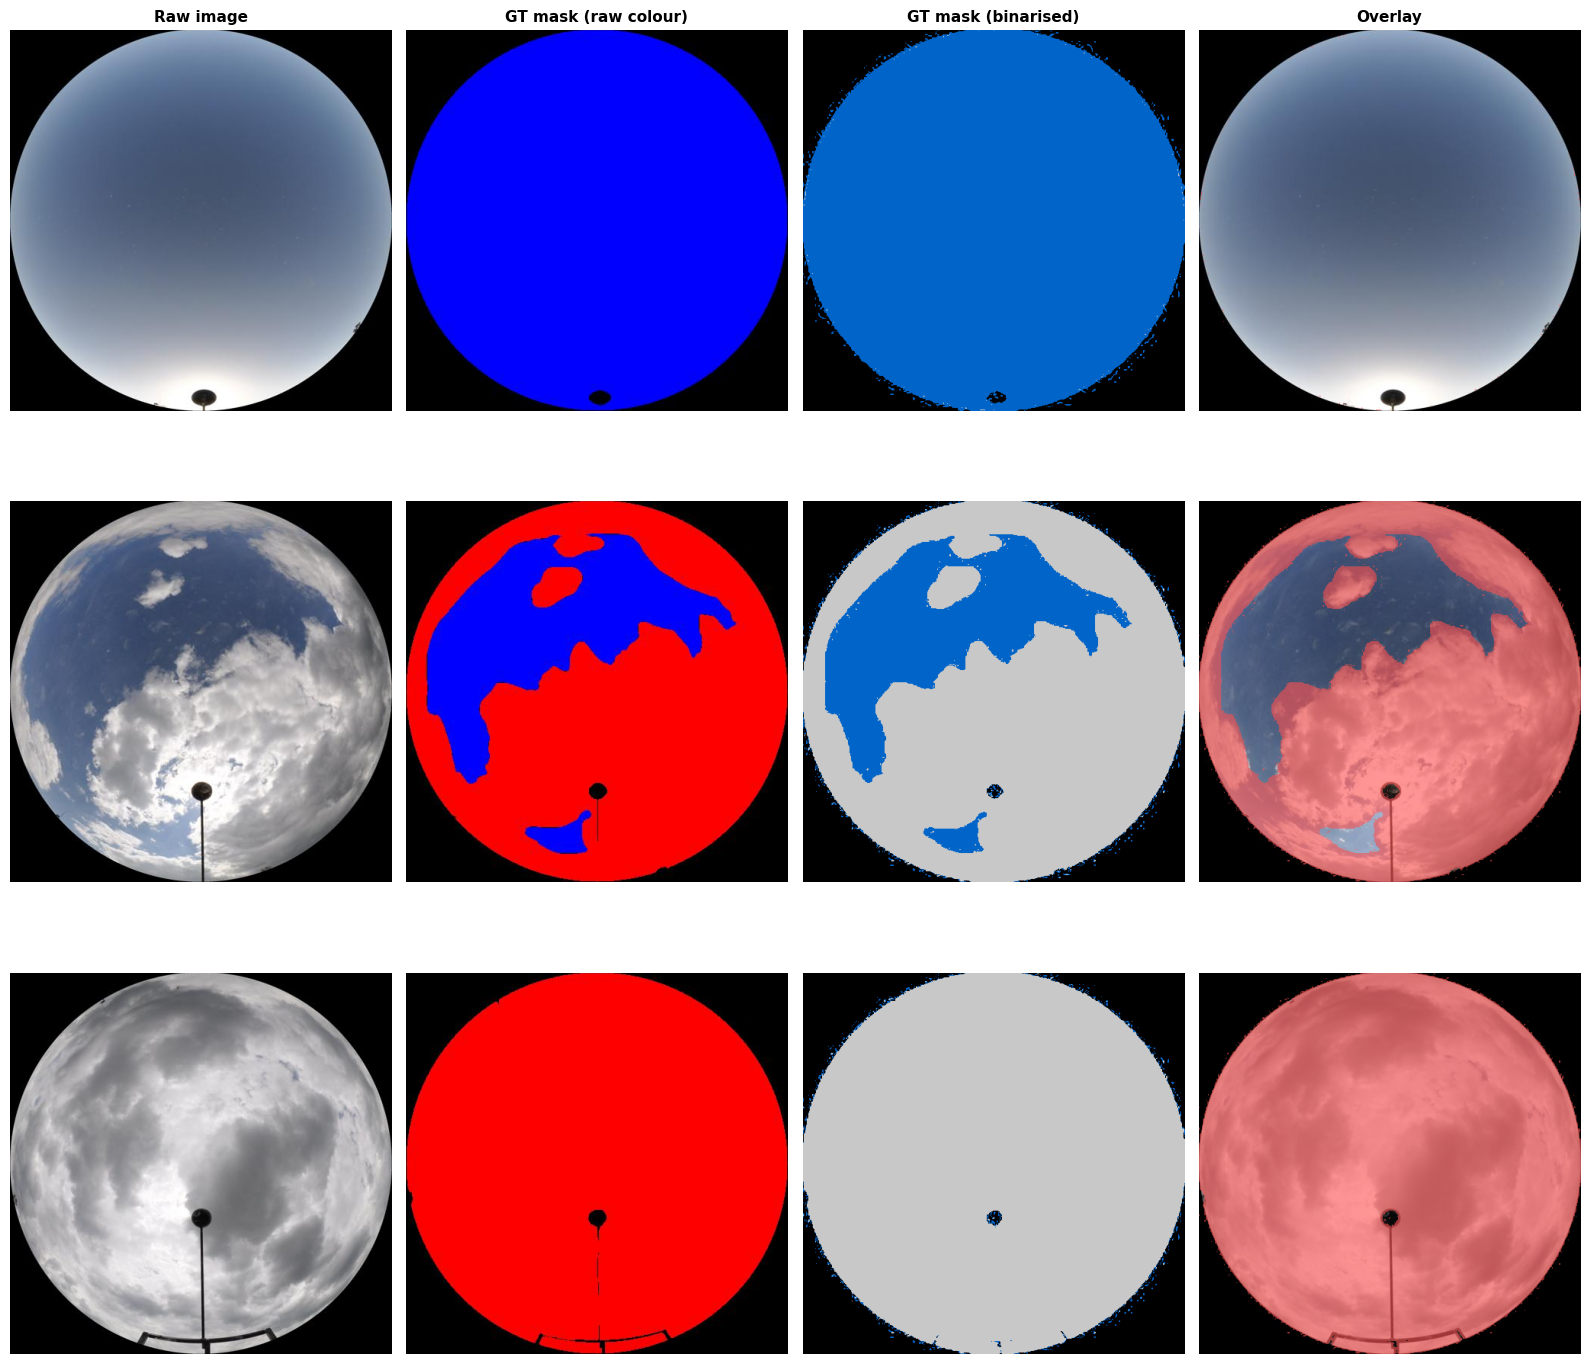

In [8]:
# Show one pair from CF levels 0, 5, 10
SHOW_LEVELS = [0, 5, 10]
fig, axes = plt.subplots(len(SHOW_LEVELS), 4, figsize=(16, 5 * len(SHOW_LEVELS)))

col_titles = ['Raw image', 'GT mask (raw colour)', 'GT mask (binarised)', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold')

for row_idx, level in enumerate(SHOW_LEVELS):
    row = df_acs[df_acs['cf_level'] == level].iloc[0]
    img, mask = load_acs_wsi_pair(row['image_path'], row['mask_path'])

    # Area-weighted CF using cosine-zenith weights (inferred dome geometry)
    from skycamera.preprocessing import _infer_dome_params
    cx_, cy_, r_ = _infer_dome_params(mask)
    w_map = build_zenith_weight_map(mask.shape[0], mask.shape[1], cx_, cy_, r_, CF_MAX_ZENITH_DEG)
    cf_measured = weighted_cf(mask, w_map)

    # Load raw GT mask for colour visualisation
    import cv2
    bgr_gt = cv2.imread(str(row['mask_path']))
    rgb_gt = cv2.cvtColor(bgr_gt, cv2.COLOR_BGR2RGB)

    # Binarised mask display
    mask_display = np.zeros((*mask.shape, 3), dtype=np.uint8)
    mask_display[mask == 1] = [200, 200, 200]   # cloud = light grey
    mask_display[mask == 0] = [0, 100, 200]      # sky   = blue
    mask_display[mask == 255] = [0, 0, 0]         # outside = black

    # Overlay: cloud pixels red on original image
    overlay = img.copy()
    overlay[mask == 1] = (overlay[mask == 1] * 0.4 + np.array([255, 80, 80]) * 0.6).astype(np.uint8)

    axes[row_idx][0].imshow(img)
    axes[row_idx][0].set_ylabel(f'Level {level}\ncf_approx={row["cf_approx"]:.2f}\ncf_measured={cf_measured:.3f}',
                                 fontsize=9)
    axes[row_idx][1].imshow(rgb_gt)
    axes[row_idx][2].imshow(mask_display)
    axes[row_idx][3].imshow(overlay)
    for ax in axes[row_idx]: ax.axis('off')

fig.tight_layout()
plt.savefig('../outputs/plots/acs_wsi_samples.png', bbox_inches='tight', dpi=100)
plt.show()

## 6. ACS_WSI cloud fraction distribution

Compute measured CF for all 77 pairs and compare against the folder-label midpoints.

In [9]:
from skycamera.preprocessing import _infer_dome_params

cf_measured_all = []
for _, row in df_acs.iterrows():
    img, mask = load_acs_wsi_pair(row['image_path'], row['mask_path'])
    cx_, cy_, r_ = _infer_dome_params(mask)
    w_map = build_zenith_weight_map(mask.shape[0], mask.shape[1], cx_, cy_, r_, CF_MAX_ZENITH_DEG)
    cf_measured_all.append(weighted_cf(mask, w_map))

df_acs = df_acs.copy()
df_acs['cf_measured'] = cf_measured_all

print(f'Area-weighted CF (cosine-zenith, max zenith={CF_MAX_ZENITH_DEG}°)')
print('Measured CF per level (mean across 7 images each):')
print(df_acs.groupby('cf_level')[['cf_approx', 'cf_measured']].mean().round(3).to_string())

Area-weighted CF (cosine-zenith, max zenith=70.0°)
Measured CF per level (mean across 7 images each):
          cf_approx  cf_measured
cf_level                        
0               0.0        0.000
1               0.1        0.027
2               0.2        0.238
3               0.3        0.510
4               0.4        0.596
5               0.5        0.625
6               0.6        0.803
7               0.7        0.829
8               0.8        0.946
9               0.9        0.989
10              1.0        0.999


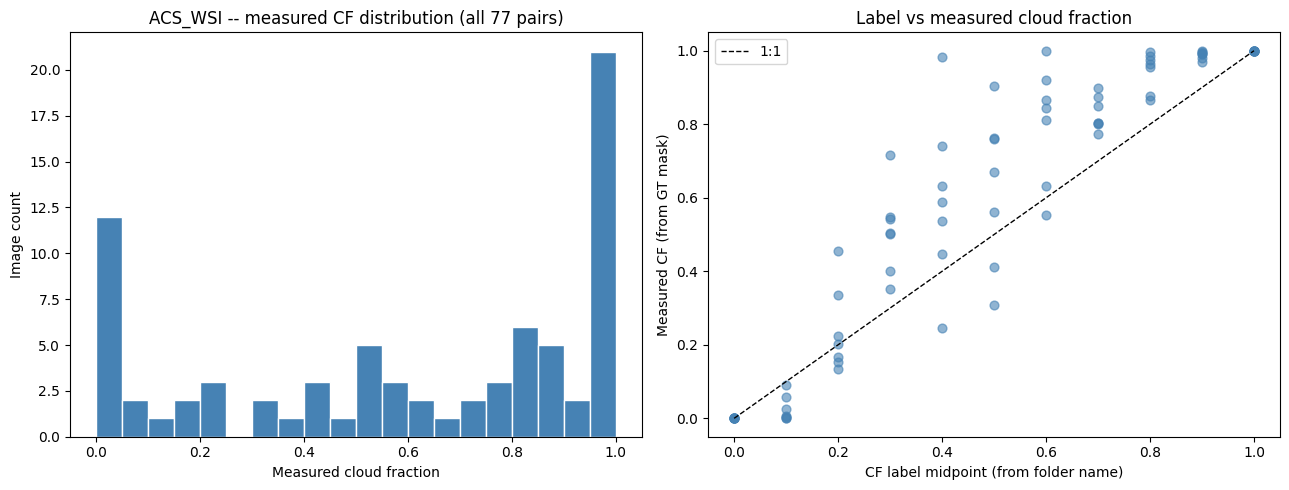

Total pairs: 77
Pairs per CF level: 7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of measured CF
axes[0].hist(df_acs['cf_measured'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Measured cloud fraction')
axes[0].set_ylabel('Image count')
axes[0].set_title('ACS_WSI -- measured CF distribution (all 77 pairs)')

# Measured vs label midpoint
axes[1].scatter(df_acs['cf_approx'], df_acs['cf_measured'], alpha=0.6, color='steelblue', s=40)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='1:1')
axes[1].set_xlabel('CF label midpoint (from folder name)')
axes[1].set_ylabel('Measured CF (from GT mask)')
axes[1].set_title('Label vs measured cloud fraction')
axes[1].legend()

fig.tight_layout()
plt.savefig('../outputs/plots/acs_wsi_cf_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

print(f'Total pairs: {len(df_acs)}')
print(f'Pairs per CF level: {len(df_acs) // df_acs["cf_level"].nunique()}')